CHECK :  -15.0 -15.0


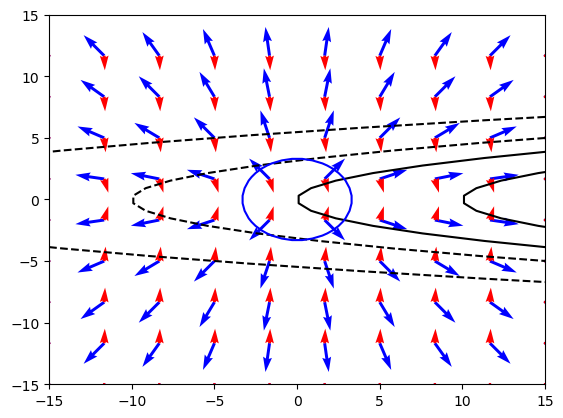

In [70]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-15, 15, 50)
y = np.linspace(-15, 15, 50)

small_x = np.linspace(-15, 15, 10)
small_y = np.linspace(-15, 15, 10)

X,Y = np.array(np.meshgrid(x,y))

smallX, smallY = np.array(np.meshgrid(small_x, small_y))

DX = 30 / 19

# f1 definition 
f = X - Y * Y
smallF = smallX - smallY * smallY

# definition of g1
g = X * X + Y * Y - 1
smallG = smallX * smallX + smallY * smallY - 1

def compute_grad(X, Y, F):
    field = np.zeros((X.shape[0], X.shape[1], 2))

    dx = X[0,1] - X[0,0]
    dy = Y[1,0] - Y[0,0]

    for i in range(1,X.shape[0] - 1):
        for j in range(1,X.shape[1] - 1):
            dFx = (F[i, j+1] - F[i, j-1]) / dx
            dFy = (F[i+1, j] - F[i-1, j]) / dy
            field[i, j] = [dFx, dFy]

    return field

constraint_field = compute_grad(smallX,smallY,smallG)

cons_field_x = constraint_field[..., 0]
cons_field_y = constraint_field[..., 1]     

function_field = compute_grad(smallX,smallY,smallF)

func_field_x = function_field[..., 0]
func_field_y = function_field[..., 1]     


fig, ax = plt.subplots()

cs = ax.contour(X,Y, f, levels=[-30, -10,0, 10, 30, 40], colors = "black")

cs = ax.contour(X,Y,g, levels=[10], colors = "blue")

print("CHECK : ",X[0][0], Y[0][0])

factor = np.sqrt(cons_field_y * cons_field_y + cons_field_x * cons_field_x) + 0.1
func_factor = np.sqrt(func_field_y * func_field_y + func_field_x * func_field_x) + 0.1

plt.quiver(smallX,smallY,cons_field_x / (factor), cons_field_y / factor, color='b', units='xy', scale=0.5)

plt.quiver(smallX,smallY,func_field_x / func_factor, func_field_y / func_factor, color='r', units='xy', scale=1)

cs.changed()
